## Entrega 2 - Churn en Olist (sin leakage) + MLflow en EC2

Este notebook:

- Descomprime OlistData.zip (ruta Windows) y define DATA_DIR.

- Construye order_level sin duplicaciones (agregando tablas 1:N por order_id).

- Define el label de churn con snapshot_date + ventana futura W y limita la población a clientes activos (lookback) para evitar incluir clientes históricamente inactivos.

- Genera features (RFM + experiencia) a nivel customer_unique_id.

- Aplica split temporal.

- Entrena y compara 2 modelos (LogReg vs RandomForest). Dado el desbalance, reporta Precision/Recall/F1 y PR-AUC para la clase no-churn (recompra)además de Accuracy.

- Ajusta el umbral de decisión para maximizar F1_nochu.
Genera artefactos (matriz de confusión, curva PR, tabla de métricas) en outputs/.

- Loggea runs y artefactos a MLflow en EC2 (nombres de métricas sanitizados, p.ej. f1_nochurn_0_).

##### Requisito clave: NO se utiliza churned = 1 si Recency > W. Aquí el churn se define mirando compras en la ventana futura (snapshot_date, snapshot_date+W].

#### CELDA 1 — ZIP → DATA_DIR + outputs

In [1]:
import os, zipfile

DATA_ZIP_PATH = r"C:\Users\aland\Downloads\OlistData.zip"
ZIP_EXTRACT_DIR = r"C:\Users\aland\Downloads\OlistData_extracted"

os.makedirs(ZIP_EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(DATA_ZIP_PATH, "r") as z:
    z.extractall(ZIP_EXTRACT_DIR)

DATA_DIR = ZIP_EXTRACT_DIR
print("DATA_DIR =", DATA_DIR)

# outputs (NECESARIO para tablas/figuras/modelos)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
print("outputs/listo")

DATA_DIR = C:\Users\aland\Downloads\OlistData_extracted
outputs/listo


#### CELDA 2 — IMPORTS BASE + SEED

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

#### CELDA 3 — CARGA DE CSV + order_level (SIN duplicación por joins)
Usamos solo 5 CSV: orders, customers, payments, reviews, items.

In [3]:
import os
import pandas as pd

orders = pd.read_csv(
    os.path.join(DATA_DIR, "olist_orders_dataset.csv"),
    parse_dates=["order_purchase_timestamp",
                 "order_delivered_customer_date",
                 "order_estimated_delivery_date"]
)

customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
payments  = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))
items     = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))

# orders + customers
orders_c = orders.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id",
    how="left"
)

# agregaciones por order_id (evita duplicación 1:N)
payments_agg = (payments.groupby("order_id", as_index=False)["payment_value"]
                .sum()
                .rename(columns={"payment_value": "payment_total"}))

reviews_agg = (reviews.groupby("order_id", as_index=False)["review_score"]
               .mean()
               .rename(columns={"review_score": "review_score_mean"}))

items_agg = (items.groupby("order_id", as_index=False)
             .agg(num_items=("order_item_id", "count"),
                  price_sum=("price", "sum"),
                  freight_sum=("freight_value", "sum")))

# order_level final
order_level = (orders_c
               .merge(payments_agg, on="order_id", how="left")
               .merge(reviews_agg,  on="order_id", how="left")
               .merge(items_agg,    on="order_id", how="left"))

# Solo entregadas para logística
order_level = order_level[order_level["order_status"] == "delivered"].copy()

# Quitar casos sin delivered_date
order_level = order_level.dropna(subset=["order_delivered_customer_date", "order_purchase_timestamp"])

# features logísticas (días)
order_level["delivery_days"] = (
    (order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"])
    .dt.total_seconds() / 86400.0
)

order_level["late_days"] = (
    (order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"])
    .dt.total_seconds() / 86400.0
)

print("order_level listo | rows:", len(order_level), "| unique orders:", order_level["order_id"].nunique())
print("duplicados order_id:", order_level["order_id"].duplicated().sum())

order_level.head()

order_level listo | rows: 96470 | unique orders: 96470
duplicados order_id: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,payment_total,review_score_mean,num_items,price_sum,freight_sum,delivery_days,late_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,4.0,1.0,29.99,8.72,8.436574,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,141.46,4.0,1.0,118.70,22.76,13.782037,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,5.0,1.0,159.90,19.22,9.394213,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,72.20,5.0,1.0,45.00,27.20,13.208750,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62,5.0,1.0,19.90,8.72,2.873877,-9.238171


#### CELDA 4 — LABEL churn (SIN leakage) + población activa (lookback)

In [4]:
import numpy as np
import pandas as pd

W = 90  # baseline Entrega 1

SNAPSHOT_OFFSET_DAYS = 180      # dónde esta el snapshot (más atrás que max_date)
ACTIVE_LOOKBACK_DAYS = 180      # población: clientes con compra reciente antes del snapshot

max_date = order_level["order_purchase_timestamp"].max()
snapshot_date = (max_date - pd.Timedelta(days=SNAPSHOT_OFFSET_DAYS)).normalize()
label_end = snapshot_date + pd.Timedelta(days=W)

print("max_date:", max_date)
print("snapshot_date:", snapshot_date)
print("label_end:", label_end)

pre  = order_level[order_level["order_purchase_timestamp"] <= snapshot_date].copy()
post = order_level[(order_level["order_purchase_timestamp"] > snapshot_date) &
                   (order_level["order_purchase_timestamp"] <= label_end)].copy()

# Clientes activos recientemente antes del snapshot
last_purchase_pre = pre.groupby("customer_unique_id")["order_purchase_timestamp"].max()
active_cutoff = snapshot_date - pd.Timedelta(days=ACTIVE_LOOKBACK_DAYS)
active_customers = last_purchase_pre[last_purchase_pre >= active_cutoff].index

base_customers = pd.DataFrame({"customer_unique_id": active_customers})

# Compras en la ventana futura (no-churn = recompra)
active_next = post.groupby("customer_unique_id").size().reset_index(name="n_orders_next")

labels = base_customers.merge(active_next, on="customer_unique_id", how="left")
labels["churned"] = np.where(labels["n_orders_next"].isna(), 1, 0)
labels = labels.drop(columns=["n_orders_next"])

print(labels["churned"].value_counts())
labels.head()

max_date: 2018-08-29 15:00:37
snapshot_date: 2018-03-02 00:00:00
label_end: 2018-05-31 00:00:00
churned
1    33949
0      282
Name: count, dtype: int64


,customer_unique_id,churned
0,0000f6ccb0745a6a4b88665a16c9f078,1
1,0004aac84e0df4da2b147fca70cf8255,1
2,00053a61a98854899e70ed204dd4bafe,1
3,00082cbe03e478190aadbea78542e933,1
4,000bfa1d2f1a41876493be685390d6d3,1


#### CELDA 5 — FEATURES a nivel cliente (RFM + experiencia) + dataset final

In [5]:
import numpy as np
import pandas as pd

# last_purchase_pre ya existe de la celda 4 (lo recalculamos por claridad)
last_purchase_pre = (pre.groupby("customer_unique_id")["order_purchase_timestamp"]
                     .max()
                     .rename("last_purchase_pre"))

# RFM
recency = ((snapshot_date - last_purchase_pre).dt.days).rename("Recency")
frequency = (pre.groupby("customer_unique_id")["order_id"].nunique()).rename("Frequency")
monetary = (pre.groupby("customer_unique_id")["payment_total"].sum()).rename("Monetary")

# Experiencia / logística
avg_review = (pre.groupby("customer_unique_id")["review_score_mean"].mean()).rename("avg_review_score")
avg_delivery = (pre.groupby("customer_unique_id")["delivery_days"].mean()).rename("avg_delivery_days")
avg_late = (pre.groupby("customer_unique_id")["late_days"].mean()).rename("avg_late_days")

avg_items = (pre.groupby("customer_unique_id")["num_items"].mean()).rename("avg_num_items")
avg_price = (pre.groupby("customer_unique_id")["price_sum"].mean()).rename("avg_price_sum")
avg_freight = (pre.groupby("customer_unique_id")["freight_sum"].mean()).rename("avg_freight_sum")

state = (pre.groupby("customer_unique_id")["customer_state"]
         .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
         .rename("customer_state"))

features = pd.concat([
    recency, frequency, monetary,
    avg_review, avg_delivery, avg_late,
    avg_items, avg_price, avg_freight,
    state, last_purchase_pre
], axis=1).reset_index()

dataset = features.merge(labels, on="customer_unique_id", how="inner")

print("dataset shape:", dataset.shape)
print("churn distribution:\n", dataset["churned"].value_counts(normalize=True))

dataset.to_csv("outputs/tables/customer_churn_dataset_v2.csv", index=False)
print("Guardado: outputs/tables/customer_churn_dataset_v2.csv")

dataset.head()

dataset shape: (34231, 13)
churn distribution:
 churned
1    0.991762
0    0.008238
Name: proportion, dtype: float64
Guardado: outputs/tables/customer_churn_dataset_v2.csv


,customer_unique_id,Recency,Frequency,Monetary,avg_review_score,avg_delivery_days,avg_late_days,avg_num_items,avg_price_sum,avg_freight_sum,customer_state,last_purchase_pre,churned
0,0000f6ccb0745a6a4b88665a16c9f078,140,1,43.62,4.0,20.037083,-11.108970,1.0,25.99,17.63,PA,2017-10-12 20:29:41,1
1,0004aac84e0df4da2b147fca70cf8255,107,1,196.89,5.0,13.141134,-7.035463,1.0,180.00,16.89,SP,2017-11-14 19:45:42,1
2,00053a61a98854899e70ed204dd4bafe,1,1,419.18,1.0,16.324421,-9.206354,2.0,382.00,37.18,PR,2018-02-28 11:15:41,1
3,00082cbe03e478190aadbea78542e933,102,1,126.26,5.0,10.273229,-7.086470,1.0,79.00,47.26,SP,2017-11-19 15:22:02,1
4,000bfa1d2f1a41876493be685390d6d3,153,1,46.85,4.5,13.960521,-12.423530,1.0,35.00,11.85,SP,2017-09-29 14:46:58,1


#### CELDA 6 — SPLIT TEMPORAL (NO train_test_split)

In [6]:
# =========================
# Split temporal (no aleatorio)
# =========================
dataset = dataset.dropna(subset=["last_purchase_pre"]).copy()

split_date = dataset["last_purchase_pre"].quantile(0.80)
train_df = dataset[dataset["last_purchase_pre"] <= split_date].copy()
test_df  = dataset[dataset["last_purchase_pre"] >  split_date].copy()

target = "churned"
drop_cols = ["customer_unique_id", "last_purchase_pre", target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target].astype(int)

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target].astype(int)

print("split_date:", split_date)
print("train:", X_train.shape, "test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))


split_date: 2018-01-31 11:43:08
train: (27385, 10) test: (6846, 10)
y_train distribution:
 churned
1    0.992441
0    0.007559
Name: proportion, dtype: float64
y_test distribution:
 churned
1    0.989045
0    0.010955
Name: proportion, dtype: float64


#### CELDA 7 — BASELINE (predice churn para todos)

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score

y_pred_all_churn = np.ones_like(y_test)
proba_churn_all1 = np.ones_like(y_test, dtype=float)

baseline = {
    "accuracy": accuracy_score(y_test, y_pred_all_churn),

    # métricas para churn=1
    "precision_churn_1": precision_score(y_test, y_pred_all_churn, pos_label=1, zero_division=0),
    "recall_churn_1": recall_score(y_test, y_pred_all_churn, pos_label=1, zero_division=0),
    "f1_churn_1": f1_score(y_test, y_pred_all_churn, pos_label=1, zero_division=0),

    # métricas para no-churn=0 (clase minoritaria)
    "precision_nochurn_0": precision_score(y_test, y_pred_all_churn, pos_label=0, zero_division=0),
    "recall_nochurn_0": recall_score(y_test, y_pred_all_churn, pos_label=0, zero_division=0),
    "f1_nochurn_0": f1_score(y_test, y_pred_all_churn, pos_label=0, zero_division=0),

    # PR-AUC para no-churn (recompra)
    "pr_auc_nochurn_0": average_precision_score(1 - y_test, 1 - proba_churn_all1),
}
baseline

{'accuracy': 0.9890446976336547,
 'precision_churn_1': 0.9890446976336547,
 'recall_churn_1': 1.0,
 'f1_churn_1': 0.9944921788940295,
 'precision_nochurn_0': 0.0,
 'recall_nochurn_0': 0.0,
 'f1_nochurn_0': 0.0,
 'pr_auc_nochurn_0': 0.010955302366345312}

#### CELDA 8 — MODELOS (LogReg + RandomForest) con preprocessing

In [8]:
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ],
    remainder="drop"
)

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

models = {"logreg": logreg, "random_forest": rf}

#### CELDA 9 — EVALUACIÓN (métricas “dobles” + artifacts)

In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score
)
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

def eval_and_plots_dual(model, X_test, y_test, threshold=0.5, prefix="model"):
    proba_churn = model.predict_proba(X_test)[:, 1]
    pred_churn = (proba_churn >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_test, pred_churn)),

        # churn=1
        "precision_churn_1": float(precision_score(y_test, pred_churn, pos_label=1, zero_division=0)),
        "recall_churn_1": float(recall_score(y_test, pred_churn, pos_label=1, zero_division=0)),
        "f1_churn_1": float(f1_score(y_test, pred_churn, pos_label=1, zero_division=0)),

        # no-churn=0 (minoritaria)
        "precision_nochurn_0": float(precision_score(y_test, pred_churn, pos_label=0, zero_division=0)),
        "recall_nochurn_0": float(recall_score(y_test, pred_churn, pos_label=0, zero_division=0)),
        "f1_nochurn_0": float(f1_score(y_test, pred_churn, pos_label=0, zero_division=0)),

        # PR-AUC no-churn
        "pr_auc_nochurn_0": float(average_precision_score(1 - y_test, 1 - proba_churn)),
    }

    # Confusion Matrix
    fig1 = plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, pred_churn)
    plt.title(f"{prefix} - Confusion Matrix")
    cm_path = f"outputs/figures/{prefix}_confusion_matrix.png"
    plt.savefig(cm_path, bbox_inches="tight")
    plt.close(fig1)

    # PR curve NO churn (recompra)
    fig2 = plt.figure()
    PrecisionRecallDisplay.from_predictions(1 - y_test, 1 - proba_churn)
    plt.title(f"{prefix} - PR Curve (NO churn / recompra)")
    pr_path = f"outputs/figures/{prefix}_pr_curve_nochurn.png"
    plt.savefig(pr_path, bbox_inches="tight")
    plt.close(fig2)

    return metrics, cm_path, pr_path

#### CELDA 10 — ENTRENAR + COMPARAR + GUARDAR CSV de métricas

Guardado: outputs/tables/metric_comparison.csv


,model,accuracy,precision_churn_1,recall_churn_1,f1_churn_1,precision_nochurn_0,recall_nochurn_0,f1_nochurn_0,pr_auc_nochurn_0
0,logreg,0.466988,0.990881,0.465367,0.633303,0.012548,0.613333,0.024592,0.035098
1,random_forest,0.989045,0.989045,1.000000,0.994492,0.000000,0.000000,0.000000,0.013528


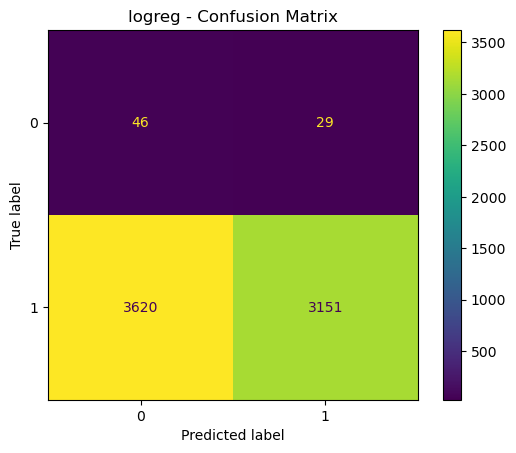

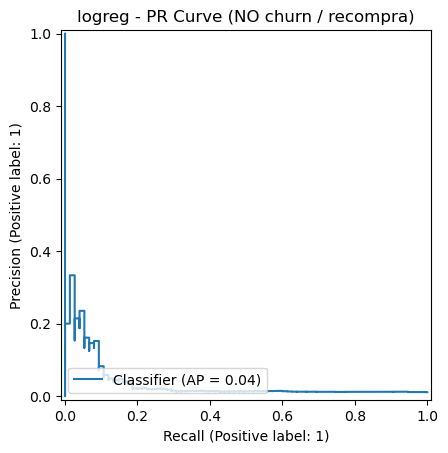

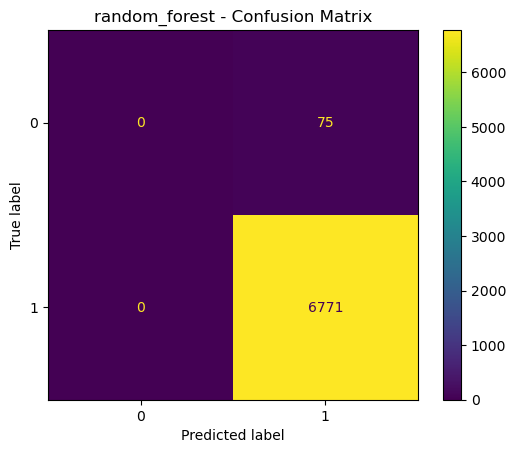

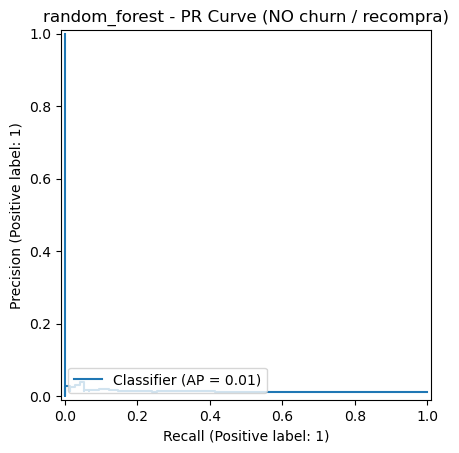

In [10]:
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics, cm_path, pr_path = eval_and_plots_dual(model, X_test, y_test, threshold=0.5, prefix=name)
    results.append({"model": name, **metrics})

results_df = pd.DataFrame(results).sort_values(by="pr_auc_nochurn_0", ascending=False)
results_df.to_csv("outputs/tables/metric_comparison.csv", index=False)

print("Guardado: outputs/tables/metric_comparison.csv")
results_df

#### CELDA 10A — Barrido de umbral (LogReg) (solo LogReg)

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# toma el modelo entrenado logreg
logreg_model = models["logreg"]
proba_churn = logreg_model.predict_proba(X_test)[:, 1]

rows = []
for thr in np.linspace(0.01, 0.99, 99):
    pred = (proba_churn >= thr).astype(int)

    rows.append({
        "threshold": float(thr),

        # no-churn (0) es la clase minoritaria
        "precision_nochurn_0": float(precision_score(y_test, pred, pos_label=0, zero_division=0)),
        "recall_nochurn_0": float(recall_score(y_test, pred, pos_label=0, zero_division=0)),
        "f1_nochurn_0": float(f1_score(y_test, pred, pos_label=0, zero_division=0)),
    })

thr_df = pd.DataFrame(rows).sort_values("f1_nochurn_0", ascending=False)
thr_df.head(10)

,threshold,precision_nochurn_0,recall_nochurn_0,f1_nochurn_0
11,0.12,0.142857,0.093333,0.112903
12,0.13,0.098592,0.093333,0.095890
9,0.10,0.151515,0.066667,0.092593
10,0.11,0.142857,0.066667,0.090909
14,0.15,0.076190,0.106667,0.088889
13,0.14,0.079545,0.093333,0.085890
6,0.07,0.210526,0.053333,0.085106
15,0.16,0.069565,0.106667,0.084211
7,0.08,0.160000,0.053333,0.080000
16,0.17,0.062016,0.106667,0.078431


#### CELDA 10B — Elegir mejor umbral y guardarlo para tablero

In [12]:
best_thr = float(thr_df.iloc[0]["threshold"])
best_f1_0 = float(thr_df.iloc[0]["f1_nochurn_0"])
print("best_threshold:", best_thr, "| best_f1_nochurn_0:", best_f1_0)

# guardar para el tablero / reporte
pd.DataFrame([{"best_threshold": best_thr, "metric": "max_f1_nochurn_0", "value": best_f1_0}]) \
  .to_csv("outputs/tables/best_threshold_logreg.csv", index=False)

print("Guardado: outputs/tables/best_threshold_logreg.csv")

best_threshold: 0.12 | best_f1_nochurn_0: 0.11290322580645161
Guardado: outputs/tables/best_threshold_logreg.csv


#### CELDA 11 — GUARDAR EL MODELO GANADOR (para tablero y MLflow)

In [13]:
from joblib import dump

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

# (Ya está entrenado en el loop, pero para seguridad lo re-entrenamos aquí)
best_model.fit(X_train, y_train)

model_path = f"outputs/models/best_model_{best_model_name}.joblib"
dump(best_model, model_path)

print("Modelo ganador:", best_model_name)
print("Guardado:", model_path)

Modelo ganador: logreg
Guardado: outputs/models/best_model_logreg.joblib


#### CELDA 12 — LISTA RÁPIDA DE ARCHIVOS GENERADOS (para verificar)

In [14]:
import glob

print("Tablas:")
print(glob.glob("outputs/tables/*"))

print("\n Figuras:")
print(glob.glob("outputs/figures/*")[:10])

print("\n Modelos:")
print(glob.glob("outputs/models/*"))

Tablas:
['outputs/tables\\best_threshold_logreg.csv', 'outputs/tables\\customer_churn_dataset_v2.csv', 'outputs/tables\\metric_comparison.csv']

 Figuras:
['outputs/figures\\logreg_C0.1_thr012_confusion_matrix.png', 'outputs/figures\\logreg_C0.1_thr012_pr_curve_nochurn.png', 'outputs/figures\\logreg_C1.0_thr012_confusion_matrix.png', 'outputs/figures\\logreg_C1.0_thr012_pr_curve_nochurn.png', 'outputs/figures\\logreg_C10.0_thr012_confusion_matrix.png', 'outputs/figures\\logreg_C10.0_thr012_pr_curve_nochurn.png', 'outputs/figures\\logreg_C1_thr005_confusion_matrix.png', 'outputs/figures\\logreg_C1_thr005_pr_curve_nochurn.png', 'outputs/figures\\logreg_C1_thr02_confusion_matrix.png', 'outputs/figures\\logreg_C1_thr02_pr_curve_nochurn.png']

 Modelos:
['outputs/models\\best_model_logreg.joblib']


#### CELDA 11A — Configurar MLflow (EC2)

In [15]:
import mlflow
import mlflow.sklearn

MLFLOW_TRACKING_URI = "http://18.205.18.75:5000"  # cambiar si IP pública cambia
EXPERIMENT_NAME = "E2_Churn_Olist"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow listo:", MLFLOW_TRACKING_URI, "| Experimento:", EXPERIMENT_NAME)

MLflow listo: http://18.205.18.75:5000 | Experimento: E2_Churn_Olist


#### CELDA 11B — Loggear runs en MLflow (mínimo 2)

In [16]:
import os
import mlflow
import mlflow.sklearn
import logging

# Silenciar logs ruidosos
logging.getLogger("mlflow.models.model").setLevel(logging.ERROR)
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)

def run_and_log(model_name, model, threshold):
    """Entrena, evalúa y registra un run completo en MLflow (params + metrics + artifacts + modelo)."""
    model.fit(X_train, y_train)
    metrics, cm_path, pr_path = eval_and_plots_dual(model, X_test, y_test, threshold=threshold, prefix=model_name)

    # MLflow requiere floats
    metrics = {k: float(v) for k, v in metrics.items()}

    with mlflow.start_run(run_name=model_name):
        # params clave del experimento (datos/definición)
        mlflow.log_param("W", W)
        mlflow.log_param("SNAPSHOT_OFFSET_DAYS", SNAPSHOT_OFFSET_DAYS)
        mlflow.log_param("ACTIVE_LOOKBACK_DAYS", ACTIVE_LOOKBACK_DAYS)
        mlflow.log_param("split_quantile", 0.80)
        mlflow.log_param("threshold", float(threshold))

        # params del pipeline/modelo
        mlflow.log_params(model.get_params())

        # métricas
        mlflow.log_metrics(metrics)

        # artifacts
        mlflow.log_artifact(cm_path)
        mlflow.log_artifact(pr_path)

        if os.path.exists("outputs/tables/metric_comparison.csv"):
            mlflow.log_artifact("outputs/tables/metric_comparison.csv")
        if os.path.exists("outputs/tables/best_threshold_logreg.csv"):
            mlflow.log_artifact("outputs/tables/best_threshold_logreg.csv")

        # modelo
        mlflow.sklearn.log_model(model, artifact_path="model")

    return metrics


#### CELDA 13 — Experimentos extra (opcional)

Logging: logreg_C0.1_thr012
🏃 View run logreg_C0.1_thr012 at: http://18.205.18.75:5000/#/experiments/1/runs/b44fff5964bb491d807f8c0ba444e1ce
🧪 View experiment at: http://18.205.18.75:5000/#/experiments/1
Logging: logreg_C1.0_thr012
🏃 View run logreg_C1.0_thr012 at: http://18.205.18.75:5000/#/experiments/1/runs/73e5ecd8f8204890ad36bbf1f6d7cec6
🧪 View experiment at: http://18.205.18.75:5000/#/experiments/1
Logging: logreg_C10.0_thr012
🏃 View run logreg_C10.0_thr012 at: http://18.205.18.75:5000/#/experiments/1/runs/59ebbc13c5704567b448acdc66ebab72
🧪 View experiment at: http://18.205.18.75:5000/#/experiments/1
Logging: logreg_C1_thr005
🏃 View run logreg_C1_thr005 at: http://18.205.18.75:5000/#/experiments/1/runs/08a8cd0af5ba4090908c5c7d9ba2a76b
🧪 View experiment at: http://18.205.18.75:5000/#/experiments/1
Logging: logreg_C1_thr02
🏃 View run logreg_C1_thr02 at: http://18.205.18.75:5000/#/experiments/1/runs/3a52d4c1d4714f4f82710236eef5bb6d
🧪 View experiment at: http://18.205.18.75:5000/#/ex

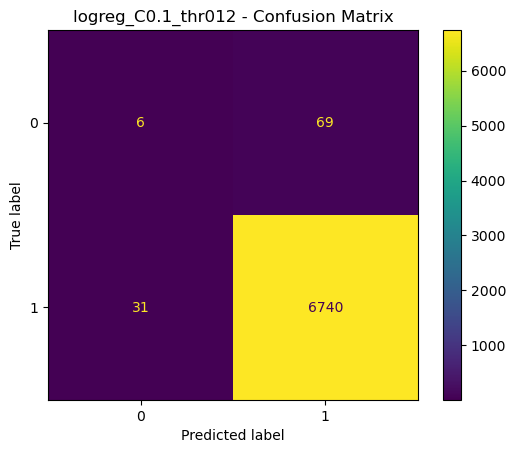

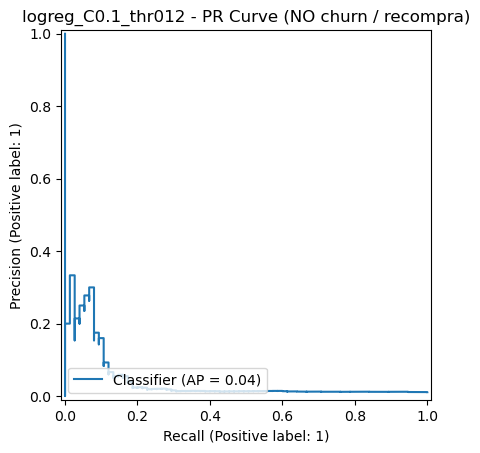

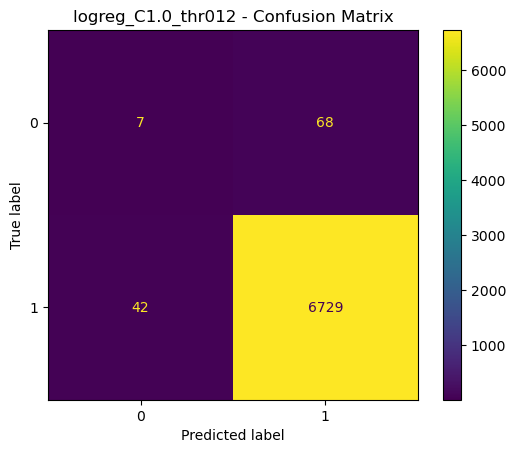

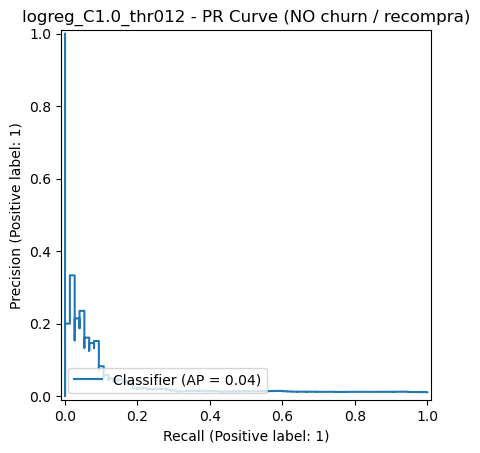

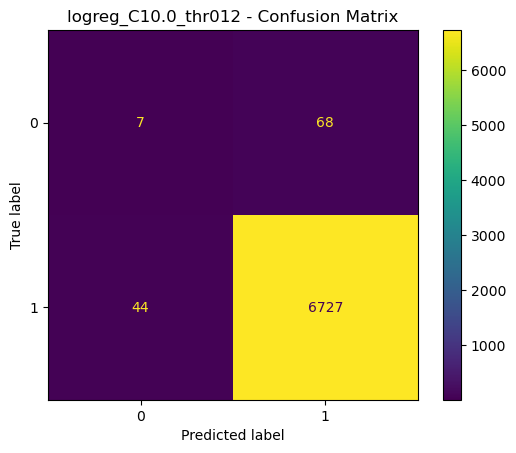

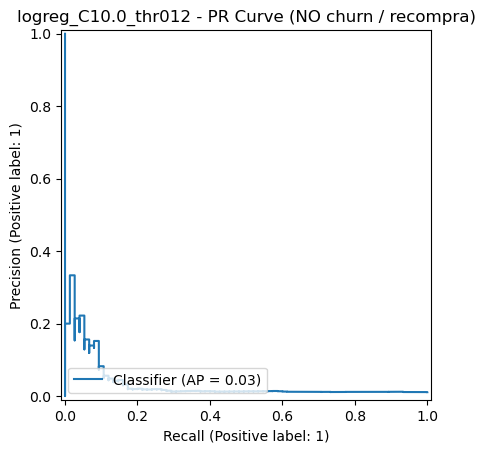

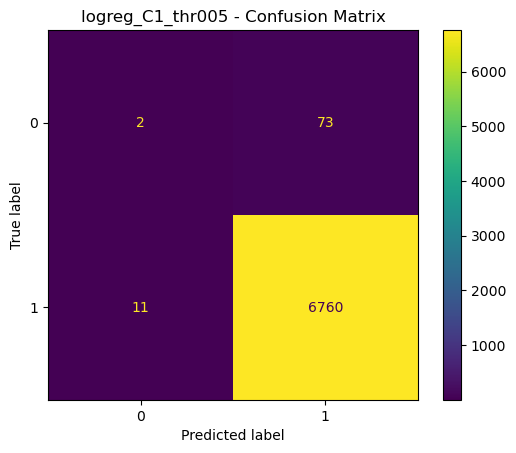

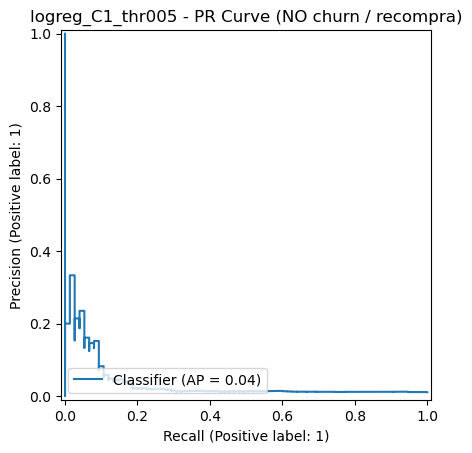

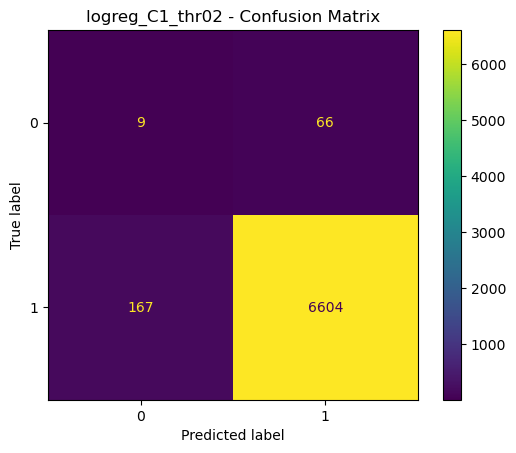

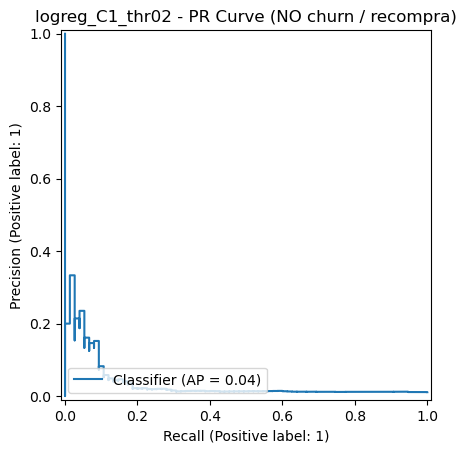

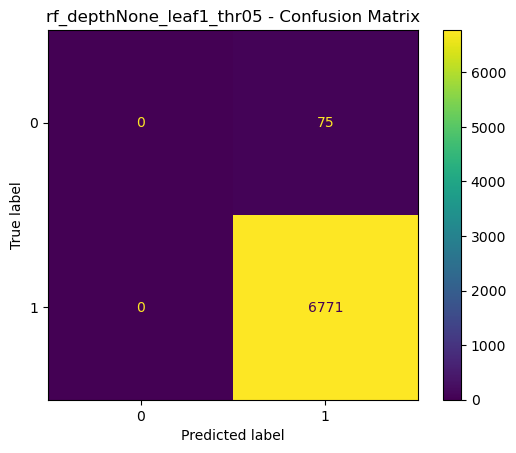

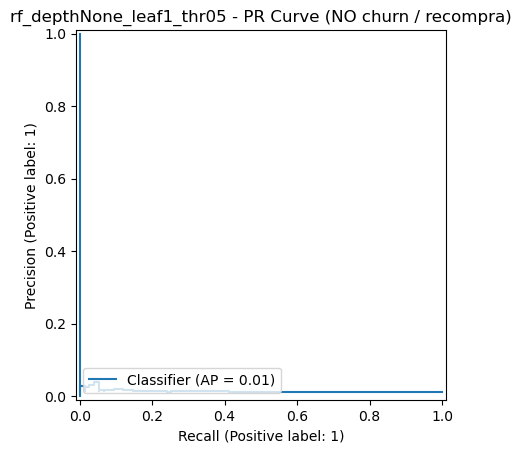

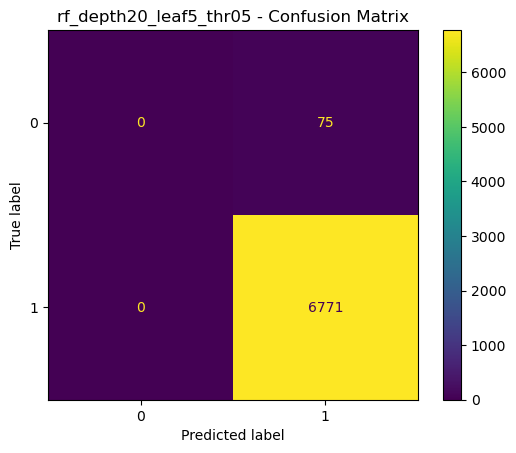

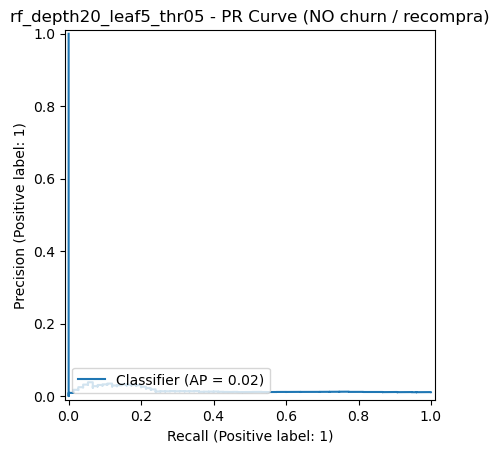

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Asegura que MLflow está apuntando a la IP correcta
import mlflow
mlflow.set_tracking_uri("http://18.205.18.75:5000")
mlflow.set_experiment("E2_Churn_Olist")

runs_to_do = []

# LogReg: variar C con threshold fijo 0.12
for C in [0.1, 1.0, 10.0]:
    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=C))
    ])
    runs_to_do.append((f"logreg_C{C}_thr012", model, 0.12))

# LogReg: variar threshold con C fijo 1.0
for thr in [0.05, 0.20]:
    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0))
    ])
    runs_to_do.append((f"logreg_C1_thr{str(thr).replace('.','')}", model, thr))

# RF: variantes
rf1 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400, random_state=42,
        class_weight="balanced_subsample", n_jobs=-1,
        max_depth=None, min_samples_leaf=1
    ))
])
runs_to_do.append(("rf_depthNone_leaf1_thr05", rf1, 0.5))

rf2 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400, random_state=42,
        class_weight="balanced_subsample", n_jobs=-1,
        max_depth=20, min_samples_leaf=5
    ))
])
runs_to_do.append(("rf_depth20_leaf5_thr05", rf2, 0.5))

# Ejecutar y loggear
for run_name, model, thr in runs_to_do:
    print("Logging:", run_name)
    _ = run_and_log(run_name, model, threshold=thr)

print("Experimentos extra loggeados")